<a href="https://colab.research.google.com/github/idialloaka-ai/DAILYCHALLENGE/blob/master/Daily_challenge_W7D1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pymuPDF spacy wordcloud
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 48.1 MB/s eta 0:00:00


In [8]:
try:
    import fitz
except ImportError:
    !pip install pymupdf
    import fitz

import re
import nltk
from nltk.corpus import stopwords
import spacy
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os

# Téléchargements NLTK
nltk.download('stopwords')

# Utilisation des noms de fichiers exacts importés par l'utilisateur
file_paths = [
    "/content/The Project Gutenberg eBook of Alice's Adventures in Wonderland.pdf",
    "/content/The Project Gutenberg eBook of Through the Looking-Glass.pdf",
    "/content/The Project Gutenberg eBook of A Tangled Tale.pdf"
]

def load_texts_from_pdfs(paths):
    corpus = []
    for path in paths:
        if not os.path.exists(path):
            print(f"Attention : Le fichier {path} est introuvable.")
            corpus.append("")
            continue
        doc = fitz.open(path)
        text = ""
        for page in doc:
            text += page.get_text()

        # Nettoyage et mise en minuscules
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text = " ".join(text.split()).lower()
        corpus.append(text)
    return corpus

corpus = load_texts_from_pdfs(file_paths)
print(f"Chargement terminé : {len([c for c in corpus if c])} fichiers lus avec succès.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Chargement terminé : 3 fichiers lus avec succès.


In [9]:
# 2. Imprimer les 200 premiers caractères de chaque texte
book_names = ["Alice's Adventures", "Through the Looking-Glass", "A Tangled Tale"]

for name, text in zip(book_names, corpus):
    print(f"--- {name} ---")
    print(text[:200], "\n")

--- Alice's Adventures ---
the project gutenberg ebook of alices adventures in wonderland this ebook is for the use of anyone anywhere in the united states and most other parts of the world at no cost and with almost no restric 

--- Through the Looking-Glass ---
the project gutenberg ebook of through the lookingglass this ebook is for the use of anyone anywhere in the united states and most other parts of the world at no cost and with almost no restrictions w 

--- A Tangled Tale ---
the project gutenberg ebook of a tangled tale this ebook is for the use of anyone anywhere in the united states and most other parts of the world at no cost and with almost no restrictions whatsoever  



### 3. Analyse Morphosyntaxique (POS Tagging) et NER
Nous utilisons spaCy pour extraire les étiquettes de parties du discours et les entités nommées.

In [10]:
import spacy
import sys

# Chargement du modèle avec gestion automatique du téléchargement
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("Téléchargement du modèle spaCy...")
    !python -m spacy download en_core_web_sm
    nlp = spacy.load('en_core_web_sm')

def analyze_text(text):
    # On limite la taille du texte pour éviter les dépassements de mémoire
    doc = nlp(text[:100000])
    # POS Tagging (étiquetage morphosyntaxique)
    pos_counts = doc.count_by(spacy.attrs.POS)
    # NER (Reconnaissance d'entités nommées)
    entities = [(ent.text, ent.label_) for ent in doc.ents[:10]]
    return pos_counts, entities

if 'book_names' in globals() and 'corpus' in globals():
    for name, text in zip(book_names, corpus):
        pos, ents = analyze_text(text)
        print(f"--- Analyse de {name} ---")
        print(f"Entités détectées : {ents}\n")
else:
    print("Erreur : Les variables 'book_names' ou 'corpus' ne sont pas définies. Veuillez exécuter la cellule de chargement des PDFs.")

--- Analyse de Alice's Adventures ---
Entités détectées : [('the united states', 'GPE'), ('the united states', 'GPE'), ('june', 'DATE'), ('june', 'DATE'), ('english', 'NORP'), ('arthur dibianca', 'PERSON'), ('david widger', 'PERSON'), ('millennium', 'DATE'), ('chapter iii', 'LAW'), ('caterpillar', 'ORG')]

--- Analyse de Through the Looking-Glass ---
Entités détectées : [('the united states', 'GPE'), ('the united states', 'GPE'), ('june', 'DATE'), ('june', 'DATE'), ('english', 'NORP'), ('david', 'PERSON'), ('millennium', 'DATE'), ('tweedledee daisy daisy', 'PERSON'), ('knight tweedledum', 'PERSON'), ('daisy daisy lion red illustration', 'PERSON')]

--- Analyse de A Tangled Tale ---
Entités détectées : [('the united states', 'GPE'), ('the united states', 'GPE'), ('june', 'DATE'), ('january', 'DATE'), ('english', 'NORP'), ('chris', 'PERSON'), ('carla', 'PERSON'), ('lindy walsh', 'PERSON'), ('linda cantoni', 'PERSON'), ('chris', 'PERSON')]



### 4. Comparaison : Racinisation vs Lemmatisation
La **racinisation (stemming)** coupe brutalement les suffixes (ex: 'running' -> 'run'), ce qui peut créer des non-mots. La **lemmatisation** utilise un dictionnaire pour revenir à la forme canonique (le lemme), ce qui est plus précis pour l'analyse sémantique.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

def lemmatize_corpus(texts):
    lemmatized_list = []
    for text in texts:
        if not text.strip():
            lemmatized_list.append("")
            continue
        doc = nlp(text[:50000])
        lemmatized_list.append(" ".join([token.lemma_ for token in doc if not token.is_stop]))
    return lemmatized_list

if 'corpus' in globals() and any(text.strip() for text in corpus):
    corpus_lemmed = lemmatize_corpus(corpus)
    # On vérifie qu'il y a du contenu après lemmatisation pour éviter l'erreur 'empty vocabulary'
    if any(text.strip() for text in corpus_lemmed):
        vectorizer = TfidfVectorizer(max_features=10)
        tfidf_matrix = vectorizer.fit_transform(corpus_lemmed)
        print("Mots clés (TF-IDF) perçus :", vectorizer.get_feature_names_out())
    else:
        print("Erreur : Le corpus lemmatisé est vide (uniquement des stop words ou du texte vide).")
else:
    print("Erreur : Le corpus est vide. Veuillez téléverser les fichiers PDF dans /content/ et relancer la cellule de chargement.")

Mots clés (TF-IDF) perçus : ['alice' 'come' 'go' 'know' 'like' 'little' 'look' 'not' 'say' 'think']


### 6. Nuage de mots (basé sur le texte lemmatisé)
L'utilisation des lemmes permet de regrouper 'said', 'say' et 'saying' sous une seule entrée plus significative.

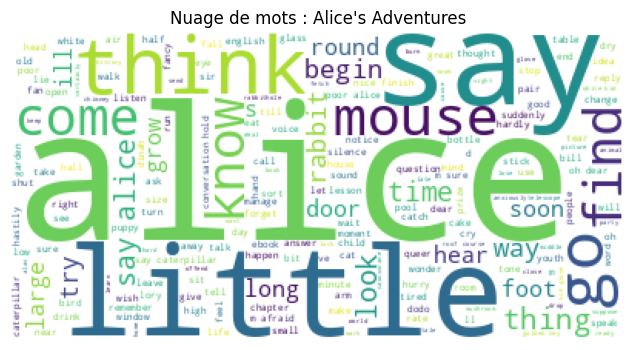

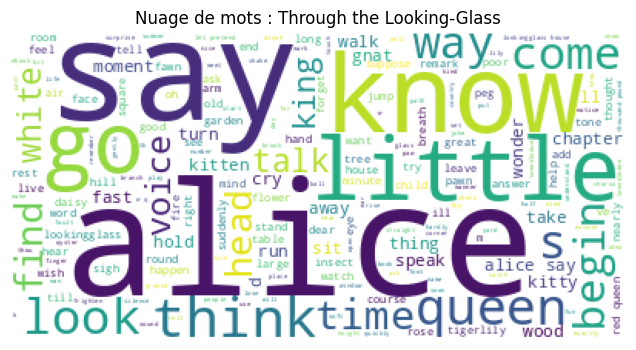

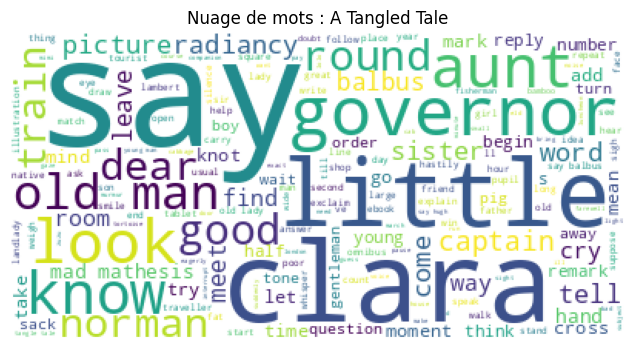

In [12]:
for i, name in enumerate(book_names):
    wordcloud = WordCloud(background_color='white').generate(corpus_lemmed[i])
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud)
    plt.title(f"Nuage de mots : {name}")
    plt.axis('off')
    plt.show()

### 8. Visualisation de la fréquence des mots (Top 5)
Ce diagramme circulaire montre la distribution des 5 termes les plus fréquents après lemmatisation pour chaque œuvre.

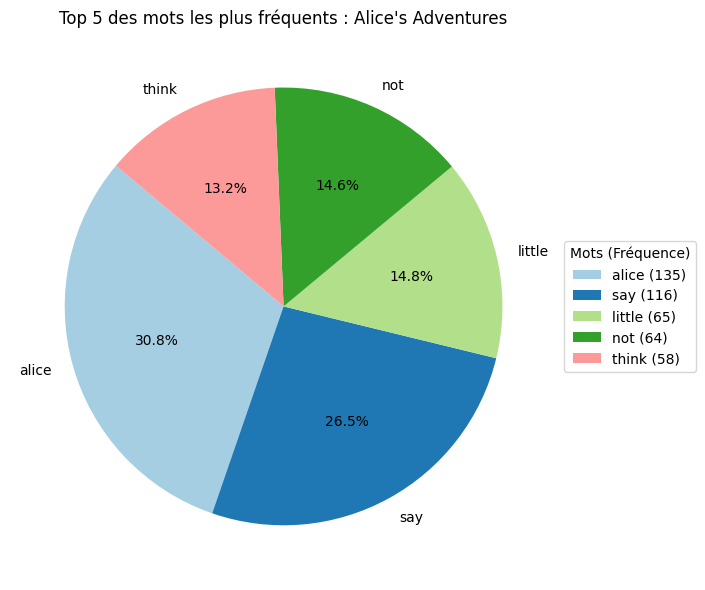

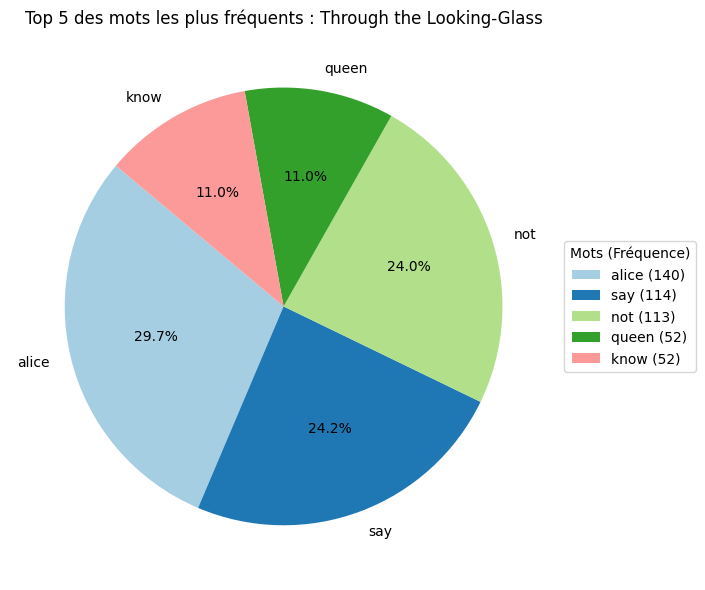

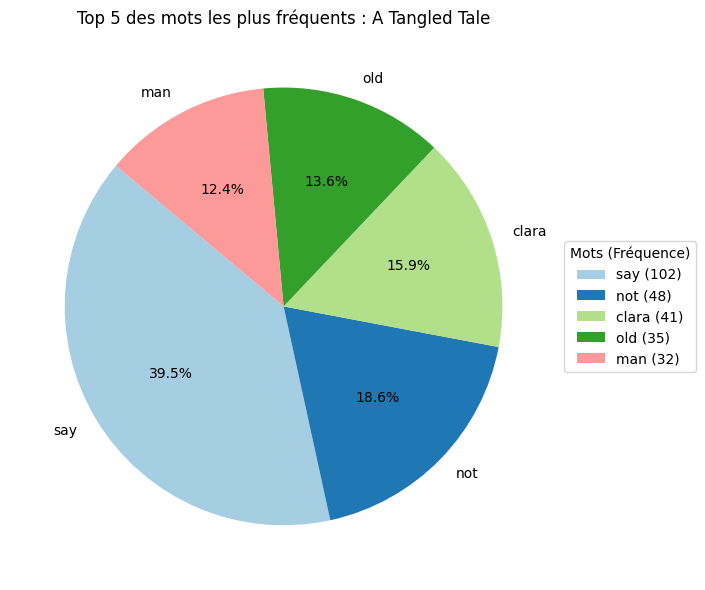

In [13]:
from collections import Counter

for i, name in enumerate(book_names):
    if not corpus_lemmed[i]:
        continue

    # Extraction et comptage des mots
    mots = corpus_lemmed[i].split()
    compteur = Counter(mots)
    top_5 = compteur.most_common(5)

    labels = [item[0] for item in top_5]
    values = [item[1] for item in top_5]
    legend_labels = [f"{word} ({count})" for word, count in top_5]

    plt.figure(figsize=(10, 6))
    plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
    plt.title(f"Top 5 des mots les plus fréquents : {name}")
    plt.legend(legend_labels, title="Mots (Fréquence)", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    plt.tight_layout()
    plt.show()

### 7. Analyse de la pertinence des résultats

**Comparaison Racinisation vs Lemmatisation :**
La racinisation (stemming) est une méthode heuristique qui tronque les mots (ex: 'flies' -> 'fli'). La lemmatisation est plus sophistiquée car elle utilise un vocabulaire et une analyse morphologique pour renvoyer la forme de base du mot (ex: 'flies' -> 'fly'). Pour ce projet, la lemmatisation est préférable car elle préserve le sens sémantique, essentiel pour un nuage de mots lisible.

**Analyse du modèle Sac de Mots (BoW) :**
Le modèle BoW permet de quantifier l'importance des termes dans chaque livre. Cependant, sans lemmatisation, les résultats seraient pollués par des variantes grammaticales du même mot. L'utilisation des lemmes ici rend le comptage beaucoup plus représentatif des thèmes réels abordés par Lewis Carroll.